In [15]:
# --- Descargar coordenadas INVEMAR desde GBIF/SiB Colombia ---
import zipfile
import urllib.request
import os

url = "https://ipt.biodiversidad.co/sibm/archive.do?r=invemar_estructura_manglar&v=1.0"
zip_path = "../data/validation/invemar_manglar.zip"
extract_dir = "../data/validation/invemar_manglar/"

print("Descargando dataset INVEMAR...")
urllib.request.urlretrieve(url, zip_path)
print("Descomprimiendo...")
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_dir)

# Leer el archivo de eventos (tiene las coordenadas)
files = os.listdir(extract_dir)
print(f"Archivos: {files}")

# Buscar el archivo de eventos
event_file = [f for f in files if 'event' in f.lower()]
print(f"Archivo de eventos: {event_file}")

# Leer
for f in files:
    if f.endswith('.txt') or f.endswith('.csv'):
        sample = pd.read_csv(os.path.join(extract_dir, f), sep='\t', nrows=3)
        print(f"\n--- {f} ---")
        print(sample.columns.tolist())

Descargando dataset INVEMAR...
Descomprimiendo...
Archivos: ['eml.xml', 'event.txt', 'extendedmeasurementorfact.txt', 'meta.xml', 'occurrence.txt']
Archivo de eventos: ['event.txt']

--- event.txt ---
['id', 'type', 'institutionCode', 'eventID', 'parentEventID', 'eventDate', 'eventTime', 'year', 'month', 'day', 'verbatimEventDate', 'continent', 'country', 'countryCode', 'stateProvince', 'locality', 'verbatimLocality', 'decimalLatitude', 'decimalLongitude', 'geodeticDatum']

--- extendedmeasurementorfact.txt ---
['id', 'occurrenceID', 'measurementType', 'measurementValue', 'measurementUnit']

--- occurrence.txt ---
['id', 'type', 'institutionID', 'institutionCode', 'basisOfRecord', 'occurrenceID', 'recordedBy', 'occurrenceStatus', 'previousIdentifications', 'eventID', 'parentEventID', 'eventDate', 'eventTime', 'year', 'month', 'day', 'verbatimEventDate', 'continent', 'country', 'countryCode', 'stateProvince', 'locality', 'verbatimLocality', 'decimalLatitude', 'decimalLongitude', 'geodet

In [16]:
# --- Extraer estaciones INVEMAR con coordenadas exactas ---
events = pd.read_csv('../data/validation/invemar_manglar/event.txt', sep='\t')

# Filtrar solo CGSM (Magdalena)
cgsm_events = events[events['stateProvince'] == 'Magdalena'].copy()

# Estaciones únicas con coordenadas
estaciones = (cgsm_events.groupby('locality')
              .agg({'decimalLatitude': 'mean', 'decimalLongitude': 'mean'})
              .reset_index())

print(f"Estaciones INVEMAR en CGSM:\n")
for _, row in estaciones.iterrows():
    print(f"  {row['locality']}: [{row['decimalLongitude']:.6f}, {row['decimalLatitude']:.6f}]")

print(f"\nTotal: {len(estaciones)} estaciones")


Estaciones INVEMAR en CGSM:

  Buritaca, Buritaca 1, Estación Buritac1-1: [-73.773962, 11.258032]
  Buritaca, Buritaca 1, Estación Buritc1-1: [-73.772154, 11.261602]
  Buritaca, Buritaca 2, Estación Buritac2-1: [-73.758606, 11.264270]
  Ciénaga Grande de Santa Marta, Isla Boquerón, Estación IBoqrn-1: [-74.301599, 10.961477]
  Ciénaga Grande de Santa Marta, Isla Boquerón, Estación IBoqrn-2: [-74.298786, 10.962590]
  Ciénaga Grande de Santa Marta, Isla Boquerón, Estación IBoqrn-3: [-74.294986, 10.962699]
  Ciénaga Grande de Santa Marta, Punta Cerro, Estación PtaCerro-1: [-74.282590, 10.969177]
  Ciénaga Grande de Santa Marta, Punta Cerro, Estación PtaCerro-2: [-74.283533, 10.974273]
  Ciénaga Grande de Santa Marta, Punta Cerro, Estación PtaCerro-3: [-74.283494, 10.975778]
  Ciénaga Grande de Santa Marta, Punta Chino, Estación PtaChino-1: [-74.308320, 10.909670]
  Ciénaga Grande de Santa Marta, Punta Chino, Estación PtaChino-2: [-74.305416, 10.912063]
  Ciénaga Grande de Santa Marta, Punt

In [17]:
# --- Filtrar solo estaciones de la CGSM y agrupar por sitio ---
cgsm_only = cgsm_events[
    cgsm_events['locality'].str.contains('Ciénaga Grande|Sff Cgsm|Vipis|Pajarales|Salamanca', 
                                          case=False, na=False)
].copy()

# Agrupar por sitio (sin el número de estación)
cgsm_only['sitio'] = cgsm_only['locality'].apply(
    lambda x: x.split(', Estación')[0] if ', Estación' in x else x
)

sitios = (cgsm_only.groupby('sitio')
          .agg({'decimalLatitude': 'mean', 'decimalLongitude': 'mean',
                'locality': 'count'})
          .rename(columns={'locality': 'n_muestreos'})
          .reset_index())

print("=== ESTACIONES INVEMAR EN LA CGSM ===\n")
for _, row in sitios.iterrows():
    print(f"  {row['sitio']}")
    print(f"    Coord: [{row['decimalLongitude']:.6f}, {row['decimalLatitude']:.6f}]")
    print(f"    Muestreos: {row['n_muestreos']}")
    print()

print(f"Total: {len(sitios)} sitios")

=== ESTACIONES INVEMAR EN LA CGSM ===

  Ciénaga Grande de Santa Marta, Isla Boquerón
    Coord: [-74.298457, 10.962255]
    Muestreos: 15

  Ciénaga Grande de Santa Marta, Punta Cerro
    Coord: [-74.283206, 10.973076]
    Muestreos: 15

  Ciénaga Grande de Santa Marta, Punta Chino
    Coord: [-74.304827, 10.912032]
    Muestreos: 15

  Ciénaga Grande de Santa Marta, Río Sevilla
    Coord: [-74.325228, 10.880496]
    Muestreos: 15

  Sff Cgsm-centrosur, Caño Palos
    Coord: [-74.471258, 10.757558]
    Muestreos: 10

Total: 5 sitios


In [19]:
# --- Ver TODAS las estaciones en el departamento del Magdalena ---
all_sites = events[events['stateProvince'] == 'Magdalena'].copy()
all_sites['sitio'] = all_sites['locality'].apply(
    lambda x: x.split(', Estación')[0] if ', Estación' in x else x
)

sitios_all = (all_sites.groupby('sitio')
              .agg({'decimalLatitude': 'mean', 'decimalLongitude': 'mean',
                    'locality': 'count'})
              .rename(columns={'locality': 'n'})
              .reset_index())

# Filtrar por coordenadas dentro del AOI de la CGSM
sitios_cgsm = sitios_all[
    (sitios_all['decimalLatitude'] > 10.3) & 
    (sitios_all['decimalLatitude'] < 11.1) &
    (sitios_all['decimalLongitude'] > -74.9) & 
    (sitios_all['decimalLongitude'] < -74.1)
]

print("=== TODAS LAS ESTACIONES EN LA ZONA CGSM ===\n")
for _, row in sitios_cgsm.iterrows():
    print(f"  {row['sitio']}")
    print(f"    [{row['decimalLongitude']:.6f}, {row['decimalLatitude']:.6f}] (n={row['n']})")
    print()

print(f"Total: {len(sitios_cgsm)} sitios")

=== TODAS LAS ESTACIONES EN LA ZONA CGSM ===

  Ciénaga Grande de Santa Marta, Isla Boquerón
    [-74.298457, 10.962255] (n=15)

  Ciénaga Grande de Santa Marta, Punta Cerro
    [-74.283206, 10.973076] (n=15)

  Ciénaga Grande de Santa Marta, Punta Chino
    [-74.304827, 10.912032] (n=15)

  Ciénaga Grande de Santa Marta, Río Sevilla
    [-74.325228, 10.880496] (n=15)

  Córdoba, Costa Verde
    [-74.243584, 11.031098] (n=1)

  Sff Cgsm-centrosur, Caño Palos
    [-74.471258, 10.757558] (n=10)

Total: 6 sitios


In [20]:
# --- SUBZONAS DEFINITIVAS: INVEMAR reales + complementarias verificadas ---

subzonas = {
    # === Estaciones INVEMAR (coordenadas exactas GBIF) ===
    'Isla_Boqueron': ee.Geometry.Point([-74.298457, 10.962255]),
    'Punta_Cerro': ee.Geometry.Point([-74.283206, 10.973076]),
    'Punta_Chino': ee.Geometry.Point([-74.304827, 10.912032]),
    'Rio_Sevilla': ee.Geometry.Point([-74.325228, 10.880496]),
    'Cano_Palos': ee.Geometry.Point([-74.471258, 10.757558]),
    'Costa_Verde': ee.Geometry.Point([-74.243584, 11.031098]),
    # === Complementarias verificadas (NDVI > 0.4) ===
    'CP_Luna': ee.Geometry.Point([-74.56, 10.87]),
    'CP_Aguas_Negras': ee.Geometry.Point([-74.57, 10.80]),
    'Cano_Clarin': ee.Geometry.Point([-74.50, 10.60]),
}

colores = {
    'Isla_Boqueron': '#F44336', 'Punta_Cerro': '#E91E63',
    'Punta_Chino': '#9C27B0', 'Rio_Sevilla': '#4CAF50',
    'Cano_Palos': '#2196F3', 'Costa_Verde': '#00BCD4',
    'CP_Luna': '#FF5722', 'CP_Aguas_Negras': '#FF9800',
    'Cano_Clarin': '#795548',
}

# Verificar NDVI
print("Verificación NDVI 2024:")
ndvi_2024 = s2.filterDate('2024-01-01','2024-12-31').select('NDVI').median()

for name, geom in subzonas.items():
    val = ndvi_2024.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=geom.buffer(500),
        scale=10
    ).get('NDVI').getInfo()
    origen = "INVEMAR" if name in ['Isla_Boqueron','Punta_Cerro','Punta_Chino','Rio_Sevilla','Cano_Palos','Costa_Verde'] else "Complementaria"
    print(f"  {name}: NDVI = {val:.3f} [{origen}]" if val else f"  {name}: sin datos [{origen}]")

# Visualizar
Map = geemap.Map(center=[10.85, -74.40], zoom=10)
rgb = s2.filterDate('2024-01-01','2024-12-31').select(['B4','B3','B2']).median().clip(aoi)
Map.addLayer(rgb, {'min': 0, 'max': 3000}, 'RGB 2024')
for name, geom in subzonas.items():
    Map.addLayer(ee.Feature(geom.buffer(500)), {'color': colores[name]}, name)
Map

Verificación NDVI 2024:
  Isla_Boqueron: NDVI = 0.302 [INVEMAR]
  Punta_Cerro: NDVI = 0.160 [INVEMAR]
  Punta_Chino: NDVI = 0.356 [INVEMAR]
  Rio_Sevilla: NDVI = 0.179 [INVEMAR]
  Cano_Palos: NDVI = 0.766 [INVEMAR]
  Costa_Verde: NDVI = 0.017 [INVEMAR]
  CP_Luna: NDVI = 0.450 [Complementaria]
  CP_Aguas_Negras: NDVI = 0.650 [Complementaria]
  Cano_Clarin: NDVI = 0.727 [Complementaria]


Map(center=[10.85, -74.4], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright'…

In [21]:
# --- SUBZONAS DEFINITIVAS ---
subzonas = {
    # INVEMAR (coordenadas exactas)
    'Isla_Boqueron': ee.Geometry.Point([-74.298457, 10.962255]),
    'Punta_Cerro': ee.Geometry.Point([-74.283206, 10.973076]),
    'Punta_Chino': ee.Geometry.Point([-74.304827, 10.912032]),
    'Rio_Sevilla': ee.Geometry.Point([-74.325228, 10.880496]),
    'Cano_Palos': ee.Geometry.Point([-74.471258, 10.757558]),
    # Complementarias (zonas no cubiertas por INVEMAR)
    'CP_Luna': ee.Geometry.Point([-74.56, 10.87]),
    'CP_Aguas_Negras': ee.Geometry.Point([-74.57, 10.80]),
    'Cano_Clarin': ee.Geometry.Point([-74.50, 10.60]),
}

colores = {
    'Isla_Boqueron': '#F44336', 'Punta_Cerro': '#E91E63',
    'Punta_Chino': '#9C27B0', 'Rio_Sevilla': '#4CAF50',
    'Cano_Palos': '#2196F3',
    'CP_Luna': '#FF5722', 'CP_Aguas_Negras': '#FF9800',
    'Cano_Clarin': '#795548',
}

print(f"Subzonas definitivas: {len(subzonas)}")
print("  5 INVEMAR (GBIF) + 3 complementarias")
print("\nExtrayendo series NDVI... (~12 min)\n")

all_data = []
for name, geom in subzonas.items():
    print(f"  {name}...", end=" ", flush=True)
    buffer = geom.buffer(500)
    for year in range(2018, 2026):
        for month in range(1, 13):
            start = ee.Date.fromYMD(year, month, 1)
            end = start.advance(1, 'month')
            monthly = s2.filterDate(start, end).select('NDVI').median()
            try:
                value = monthly.reduceRegion(
                    reducer=ee.Reducer.mean(),
                    geometry=buffer, scale=10, maxPixels=1e9
                ).get('NDVI').getInfo()
            except:
                value = None
            all_data.append({'subzona': name, 'date': f'{year}-{month:02d}-01', 'ndvi': value})
    print("OK")

df = pd.DataFrame(all_data)
df['date'] = pd.to_datetime(df['date'])
df = df.dropna(subset=['ndvi'])

print(f"\nRegistros con datos: {len(df)} de {len(all_data)}")
df.to_csv('../outputs/tables/serie_temporal_ndvi_definitiva.csv', index=False)
print("Datos guardados")

Subzonas definitivas: 8
  5 INVEMAR (GBIF) + 3 complementarias

Extrayendo series NDVI... (~12 min)

  Isla_Boqueron... OK
  Punta_Cerro... OK
  Punta_Chino... OK
  Rio_Sevilla... OK
  Cano_Palos... OK
  CP_Luna... OK
  CP_Aguas_Negras... OK
  Cano_Clarin... OK

Registros con datos: 584 de 768
Datos guardados


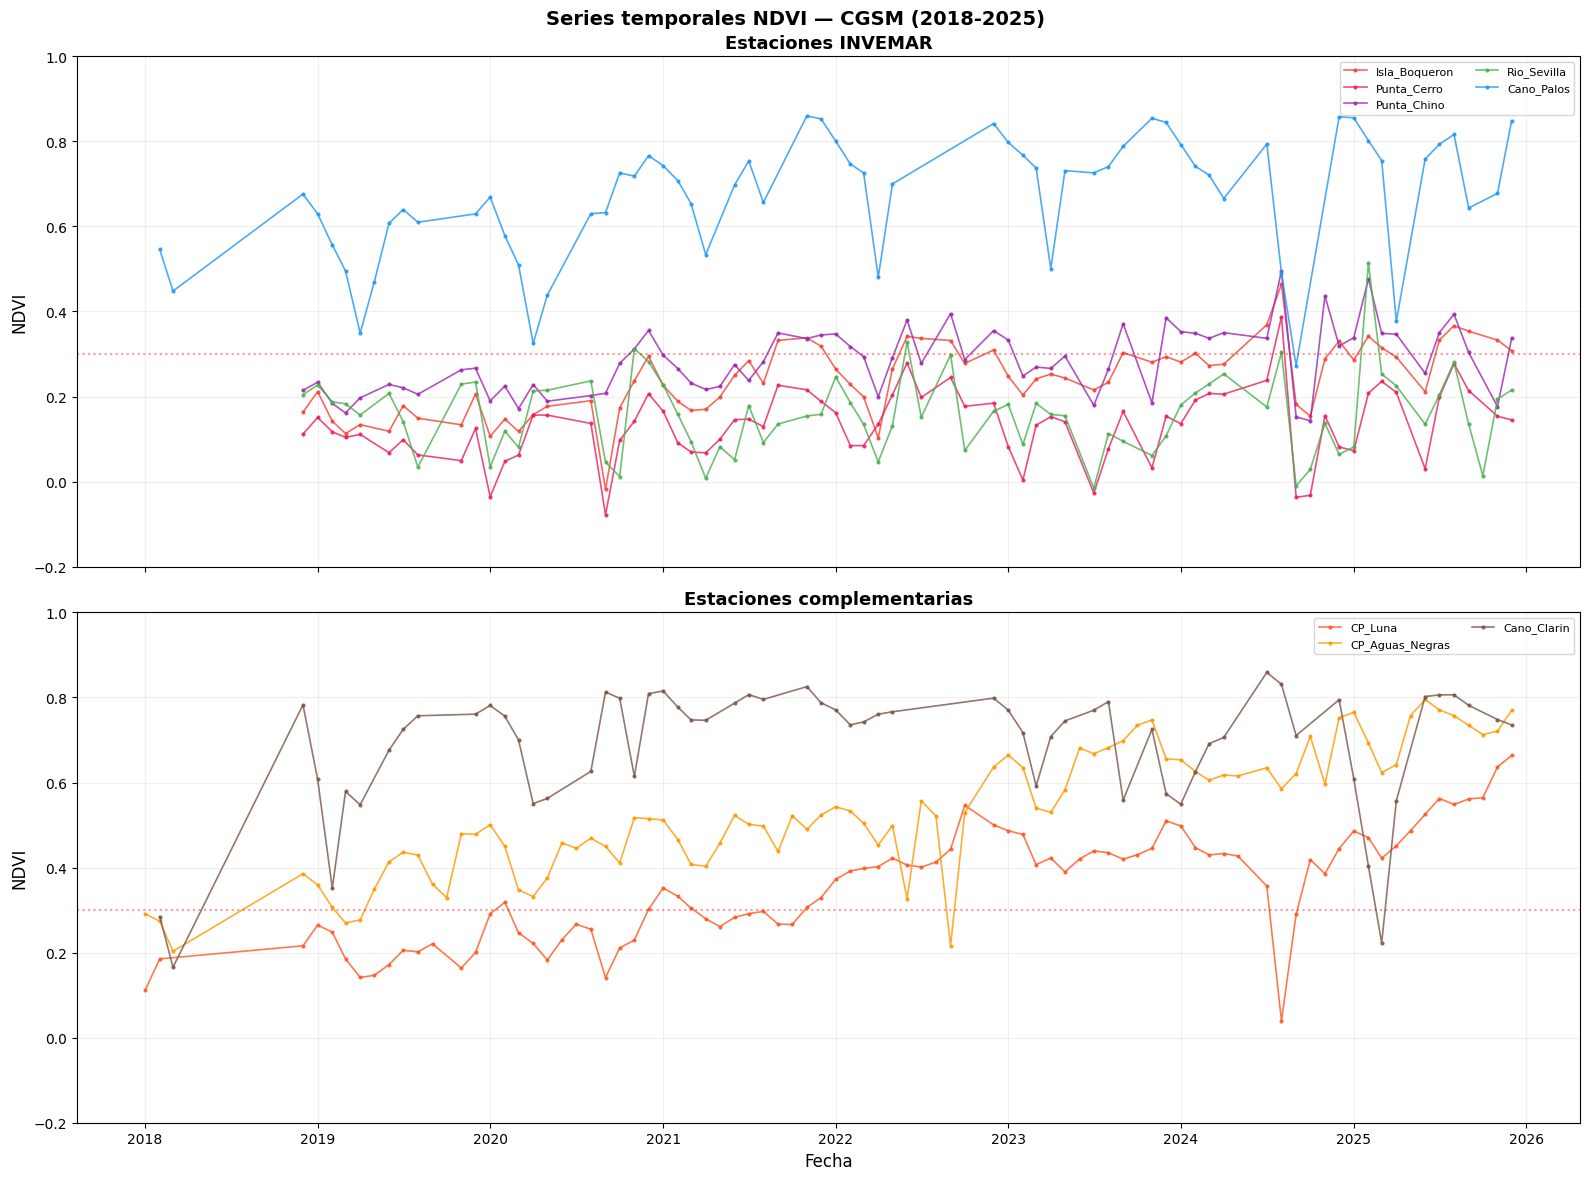

Gráfico guardado


In [25]:
# --- Gráficos de series temporales ---
grupos = {
    'Estaciones INVEMAR': ['Isla_Boqueron', 'Punta_Cerro', 'Punta_Chino', 'Rio_Sevilla', 'Cano_Palos'],
    'Estaciones complementarias': ['CP_Luna', 'CP_Aguas_Negras', 'Cano_Clarin']
}

fig, axes = plt.subplots(2, 1, figsize=(16, 12), sharex=True)

for ax, (grupo_name, estaciones) in zip(axes, grupos.items()):
    for name in estaciones:
        group = df[df['subzona'] == name].sort_values('date')
        if len(group) > 0:
            ax.plot(group['date'], group['ndvi'],
                    color=colores[name], linewidth=1.2,
                    marker='o', markersize=2, label=name, alpha=0.8)
    
    ax.set_ylabel('NDVI', fontsize=12)
    ax.set_title(grupo_name, fontsize=13, fontweight='bold')
    ax.legend(loc='upper right', fontsize=8, ncol=2)
    ax.grid(True, alpha=0.2)
    ax.set_ylim(-0.2, 1.0)
    ax.axhline(y=0.3, color='red', linestyle=':', alpha=0.4)

axes[-1].set_xlabel('Fecha', fontsize=12)
fig.suptitle('Series temporales NDVI — CGSM (2018-2025)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/serie_temporal_ndvi_definitiva.png', dpi=300, bbox_inches='tight')
plt.show()
print("Gráfico guardado")

In [26]:
# --- Z-scores y detección de anomalías ---
df['z_score'] = df.groupby('subzona')['ndvi'].transform(
    lambda x: (x - x.mean()) / x.std()
)

# Anomalías significativas
anomalias = df[df['z_score'] < -2].sort_values('z_score')
print("=== ANOMALÍAS SIGNIFICATIVAS (z-score < -2) ===\n")
if len(anomalias) > 0:
    print(anomalias[['subzona', 'date', 'ndvi', 'z_score']].to_string(index=False))
else:
    print("No se encontraron anomalías con z < -2")

# Resumen por subzona
print("\n=== RESUMEN POR SUBZONA ===\n")
for name, group in df.groupby('subzona'):
    group = group.sort_values('date')
    min_row = group.loc[group['ndvi'].idxmin()]
    max_row = group.loc[group['ndvi'].idxmax()]
    print(f"{name}:")
    print(f"  Media: {group['ndvi'].mean():.3f} | Std: {group['ndvi'].std():.3f}")
    print(f"  Mínimo: {min_row['ndvi']:.3f} ({min_row['date'].strftime('%Y-%m')})")
    print(f"  Máximo: {max_row['ndvi']:.3f} ({max_row['date'].strftime('%Y-%m')})")
    print()

# Selección de períodos críticos
print("=== PERÍODOS CRÍTICOS PARA SAMGEO ===\n")
degradacion = df.loc[df.groupby('subzona')['ndvi'].idxmin()]
print("Fechas de NDVI mínimo por estación:")
print(degradacion[['subzona', 'date', 'ndvi']].sort_values('ndvi').to_string(index=False))

# Guardar
df.to_csv('../outputs/tables/serie_ndvi_zscore_definitiva.csv', index=False)
print("\nDatos con z-score guardados")

=== ANOMALÍAS SIGNIFICATIVAS (z-score < -2) ===

        subzona       date      ndvi   z_score
    Cano_Clarin 2018-03-01  0.165526 -3.552263
    Cano_Clarin 2025-03-01  0.222663 -3.164607
  Isla_Boqueron 2020-09-01 -0.018392 -3.098545
     Cano_Palos 2024-09-01  0.272376 -2.771498
    Cano_Clarin 2018-02-01  0.284926 -2.742169
    Punta_Cerro 2020-09-01 -0.078024 -2.548778
     Cano_Palos 2020-04-01  0.324779 -2.406302
        CP_Luna 2024-08-01  0.039313 -2.405075
    Cano_Clarin 2019-02-01  0.351334 -2.291604
     Cano_Palos 2019-04-01  0.349170 -2.236320
CP_Aguas_Negras 2018-03-01  0.203301 -2.218202
CP_Aguas_Negras 2022-09-01  0.216622 -2.127675
    Punta_Cerro 2024-09-01 -0.036791 -2.048573
     Cano_Palos 2025-04-01  0.376983 -2.042489
    Punta_Cerro 2020-01-01 -0.035776 -2.036260

=== RESUMEN POR SUBZONA ===

CP_Aguas_Negras:
  Media: 0.530 | Std: 0.147
  Mínimo: 0.203 (2018-03)
  Máximo: 0.795 (2025-06)

CP_Luna:
  Media: 0.353 | Std: 0.130
  Mínimo: 0.039 (2024-08)
  Máximo

In [28]:
# --- Selección de períodos críticos para SamGeo (Fase 3) ---
import csv

periodos = {
    'degradacion': {
        'fecha_inicio': '2020-07-01',
        'fecha_fin': '2020-12-31',
        'justificacion': 'NDVI mínimo en Punta Cerro (-0.078) e Isla Boquerón (-0.018). Evento La Niña 2020.'
    },
    'recuperacion': {
        'fecha_inicio': '2022-01-01',
        'fecha_fin': '2022-06-30',
        'justificacion': 'Período post-evento con recuperación visible en estaciones costeras.'
    },
    'actual': {
        'fecha_inicio': '2024-07-01',
        'fecha_fin': '2025-06-30',
        'justificacion': 'Estado más reciente. CP_Luna muestra nueva degradación (NDVI=0.039 en ago-2024).'
    }
}

print("=== PERÍODOS CRÍTICOS SELECCIONADOS ===\n")
for periodo, info in periodos.items():
    print(f"  {periodo.upper()}")
    print(f"    Ventana: {info['fecha_inicio']} a {info['fecha_fin']}")
    print(f"    Justificación: {info['justificacion']}")
    print()

# Guardar
periodos_df = pd.DataFrame([
    {'periodo': k, **v} for k, v in periodos.items()
])
periodos_df.to_csv('../outputs/tables/periodos_criticos.csv', index=False)
print("Períodos guardados en outputs/tables/periodos_criticos.csv")

# Guardar notebook
print("\n*** FASE 2 COMPLETA — Guardar notebook con Ctrl+S ***")

=== PERÍODOS CRÍTICOS SELECCIONADOS ===

  DEGRADACION
    Ventana: 2020-07-01 a 2020-12-31
    Justificación: NDVI mínimo en Punta Cerro (-0.078) e Isla Boquerón (-0.018). Evento La Niña 2020.

  RECUPERACION
    Ventana: 2022-01-01 a 2022-06-30
    Justificación: Período post-evento con recuperación visible en estaciones costeras.

  ACTUAL
    Ventana: 2024-07-01 a 2025-06-30
    Justificación: Estado más reciente. CP_Luna muestra nueva degradación (NDVI=0.039 en ago-2024).

Períodos guardados en outputs/tables/periodos_criticos.csv

*** FASE 2 COMPLETA — Guardar notebook con Ctrl+S ***


In [2]:
import ee
import pandas as pd
import numpy as np

ee.Initialize()

aoi_coords = [
    [-74.8700, 11.0600], [-74.8200, 11.0700], [-74.7500, 11.0650],
    [-74.6800, 11.0600], [-74.6000, 11.0500], [-74.5300, 11.0400],
    [-74.4800, 11.0350], [-74.4300, 11.0300], [-74.3800, 11.0200],
    [-74.3200, 11.0100], [-74.2500, 10.9900], [-74.2000, 10.9500],
    [-74.1700, 10.9000], [-74.1500, 10.8500], [-74.1300, 10.8000],
    [-74.1200, 10.7500], [-74.1100, 10.7000], [-74.1000, 10.6500],
    [-74.1200, 10.6000], [-74.1500, 10.5500], [-74.2000, 10.5000],
    [-74.2500, 10.4500], [-74.3000, 10.4000], [-74.3500, 10.3500],
    [-74.4500, 10.3400], [-74.5500, 10.3800], [-74.6200, 10.4200],
    [-74.7000, 10.4800], [-74.7500, 10.5500], [-74.8000, 10.6500],
    [-74.8500, 10.7500], [-74.8700, 10.8500], [-74.8800, 10.9500],
    [-74.8700, 11.0600]
]
aoi = ee.Geometry.Polygon(aoi_coords)

stations = {
    'Isla Boquerón': [-74.298, 10.962],
    'Punta Cerro': [-74.283, 10.973],
    'Punta Chino': [-74.305, 10.912],
    'Río Sevilla': [-74.325, 10.880],
    'Caño Palos': [-74.471, 10.758],
    'CP Pajarales': [-74.75, 10.85],
    'Caño Clarín': [-74.55, 10.55],
    'VIPIS': [-74.65, 11.02],
}

# === LANDSAT 8 (2013–2017) ===
print("=== Landsat 8 — Serie histórica 2013–2017 ===\n")

def mask_l8(image):
    qa = image.select('QA_PIXEL')
    cloud = qa.bitwiseAnd(1 << 3).eq(0)
    shadow = qa.bitwiseAnd(1 << 4).eq(0)
    return image.updateMask(cloud.And(shadow))

def add_indices_l8(image):
    # Landsat 8: B5=NIR, B4=Red, B3=Green, B6=SWIR1
    ndvi = image.normalizedDifference(['SR_B5', 'SR_B4']).rename('NDVI')
    ndwi = image.normalizedDifference(['SR_B3', 'SR_B5']).rename('NDWI')
    cmri = ndvi.subtract(ndwi).rename('CMRI')
    return image.addBands([ndvi, ndwi, cmri])

l8 = (ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')
      .filterBounds(aoi)
      .filterDate('2013-04-01', '2017-12-31')
      .filter(ee.Filter.lt('CLOUD_COVER', 20))
      .map(mask_l8)
      .map(add_indices_l8))

print(f"Imágenes Landsat 8 disponibles: {l8.size().getInfo()}")

# === LANDSAT 9 (2022–2025) como complemento ===
l9 = (ee.ImageCollection('LANDSAT/LC09/C02/T1_L2')
      .filterBounds(aoi)
      .filterDate('2022-01-01', '2025-12-31')
      .filter(ee.Filter.lt('CLOUD_COVER', 20))
      .map(mask_l8)  # misma función de máscara
      .map(add_indices_l8))

print(f"Imágenes Landsat 9 disponibles: {l9.size().getInfo()}")

# === Extraer series mensuales NDVI por estación (Landsat 2013–2017) ===
print("\n=== Extrayendo series mensuales Landsat 8 (2013–2017) ===\n")

records = []
years = range(2013, 2018)
months = range(1, 13)

for year in years:
    for month in months:
        start = f"{year}-{month:02d}-01"
        if month == 12:
            end = f"{year+1}-01-01"
        else:
            end = f"{year}-{month+1:02d}-01"
        
        monthly = l8.filterDate(start, end).select('NDVI').median()
        
        for name, coords in stations.items():
            pt = ee.Geometry.Point(coords).buffer(500)
            try:
                val = monthly.reduceRegion(
                    reducer=ee.Reducer.mean(),
                    geometry=pt,
                    scale=30,
                    maxPixels=1e8
                ).get('NDVI').getInfo()
                
                if val is not None:
                    records.append({
                        'estacion': name,
                        'fecha': f"{year}-{month:02d}",
                        'ndvi': round(val, 4),
                        'sensor': 'Landsat 8'
                    })
            except:
                pass
        
        if len(records) % 40 == 0:
            print(f"  Procesado hasta {year}-{month:02d} ({len(records)} registros)")

df_l8 = pd.DataFrame(records)
print(f"\nTotal registros Landsat 8: {len(df_l8)}")
print(f"Rango: {df_l8['fecha'].min()} a {df_l8['fecha'].max()}")
print(f"Estaciones con datos: {df_l8['estacion'].nunique()}")

# Estadísticas por estación
print(f"\n{'Estación':<20} {'Registros':>10} {'NDVI medio':>12} {'NDVI std':>10}")
print("-" * 54)
for name in stations:
    sub = df_l8[df_l8['estacion'] == name]
    if len(sub) > 0:
        print(f"{name:<20} {len(sub):>10} {sub['ndvi'].mean():>12.3f} {sub['ndvi'].std():>10.3f}")

# Guardar
df_l8.to_csv('../outputs/tables/ndvi_landsat8_2013_2017.csv', index=False)
print(f"\nSerie Landsat guardada en outputs/tables/ndvi_landsat8_2013_2017.csv")

# === Combinar con serie Sentinel-2 si existe ===
import os
s2_csv = '../outputs/tables/ndvi_mensual_estaciones.csv'
if os.path.exists(s2_csv):
    df_s2 = pd.read_csv(s2_csv)
    df_s2['sensor'] = 'Sentinel-2'
    df_combined = pd.concat([df_l8, df_s2], ignore_index=True)
    df_combined = df_combined.sort_values(['estacion', 'fecha'])
    df_combined.to_csv('../outputs/tables/ndvi_combinado_2013_2025.csv', index=False)
    print(f"\nSerie combinada: {len(df_combined)} registros (2013–2025)")
    print(f"  Landsat 8: {len(df_l8)} | Sentinel-2: {len(df_s2)}")
else:
    print("\nNota: no se encontró la serie S2. Guarda la serie Landsat por separado.")

print("\n=== LANDSAT COMPLETO ===")

=== Landsat 8 — Serie histórica 2013–2017 ===

Imágenes Landsat 8 disponibles: 107
Imágenes Landsat 9 disponibles: 76

=== Extrayendo series mensuales Landsat 8 (2013–2017) ===

  Procesado hasta 2013-01 (0 registros)
  Procesado hasta 2013-02 (0 registros)
  Procesado hasta 2013-03 (0 registros)
  Procesado hasta 2016-05 (240 registros)

Total registros Landsat 8: 345
Rango: 2013-04 a 2017-12
Estaciones con datos: 8

Estación              Registros   NDVI medio   NDVI std
------------------------------------------------------
Isla Boquerón                45        0.151      0.029
Punta Cerro                  44        0.138      0.027
Punta Chino                  45        0.158      0.040
Río Sevilla                  45        0.160      0.026
Caño Palos                   45        0.247      0.070
CP Pajarales                 43        0.260      0.064
Caño Clarín                  35        0.244      0.062
VIPIS                        43        0.076      0.042

Serie Landsat guar

In [4]:
# === Corrección de factor de escala Landsat 8 ===
print("=== Recalculando con factor de escala corregido ===\n")

def mask_l8_v2(image):
    qa = image.select('QA_PIXEL')
    cloud = qa.bitwiseAnd(1 << 3).eq(0)
    shadow = qa.bitwiseAnd(1 << 4).eq(0)
    return image.updateMask(cloud.And(shadow))

def scale_and_indices_l8(image):
    # Aplicar factor de escala Collection 2
    optical = image.select(['SR_B2','SR_B3','SR_B4','SR_B5','SR_B6','SR_B7']).multiply(0.0000275).add(-0.2)
    # NIR=B5(index 3), Red=B4(index 2), Green=B3(index 1)
    ndvi = optical.normalizedDifference([optical.bandNames().get(3), optical.bandNames().get(2)]).rename('NDVI')
    ndwi = optical.normalizedDifference([optical.bandNames().get(1), optical.bandNames().get(3)]).rename('NDWI')
    cmri = ndvi.subtract(ndwi).rename('CMRI')
    return image.addBands([ndvi, ndwi, cmri])

l8_scaled = (ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')
      .filterBounds(aoi)
      .filterDate('2013-04-01', '2017-12-31')
      .filter(ee.Filter.lt('CLOUD_COVER', 20))
      .map(mask_l8_v2)
      .map(scale_and_indices_l8))

print(f"Imágenes Landsat 8 (escaladas): {l8_scaled.size().getInfo()}")

# Extraer series mensuales corregidas
records2 = []
for year in range(2013, 2018):
    for month in range(1, 13):
        if year == 2013 and month < 4:
            continue
        start = f"{year}-{month:02d}-01"
        if month == 12:
            end = f"{year+1}-01-01"
        else:
            end = f"{year}-{month+1:02d}-01"
        
        monthly = l8_scaled.filterDate(start, end).select('NDVI').median()
        
        for name, coords in stations.items():
            pt = ee.Geometry.Point(coords).buffer(500)
            try:
                val = monthly.reduceRegion(
                    reducer=ee.Reducer.mean(),
                    geometry=pt, scale=30, maxPixels=1e8
                ).get('NDVI').getInfo()
                
                if val is not None:
                    records2.append({
                        'estacion': name,
                        'fecha': f"{year}-{month:02d}",
                        'ndvi': round(val, 4),
                        'sensor': 'Landsat 8'
                    })
            except:
                pass
        
        if len(records2) % 80 == 0 and len(records2) > 0:
            print(f"  Procesado hasta {year}-{month:02d} ({len(records2)} registros)")

df_l8 = pd.DataFrame(records2)
print(f"\nTotal registros: {len(df_l8)}")

print(f"\n{'Estación':<20} {'Registros':>10} {'NDVI medio':>12} {'NDVI std':>10}")
print("-" * 54)
for name in stations:
    sub = df_l8[df_l8['estacion'] == name]
    if len(sub) > 0:
        print(f"{name:<20} {len(sub):>10} {sub['ndvi'].mean():>12.3f} {sub['ndvi'].std():>10.3f}")

df_l8.to_csv('../outputs/tables/ndvi_landsat8_2013_2017.csv', index=False)
print(f"\nSerie corregida guardada")

=== Recalculando con factor de escala corregido ===

Imágenes Landsat 8 (escaladas): 107
  Procesado hasta 2016-05 (240 registros)

Total registros: 345

Estación              Registros   NDVI medio   NDVI std
------------------------------------------------------
Isla Boquerón                45        0.318      0.067
Punta Cerro                  44        0.292      0.072
Punta Chino                  45        0.371      0.093
Río Sevilla                  45        0.369      0.069
Caño Palos                   45        0.616      0.132
CP Pajarales                 43        0.566      0.105
Caño Clarín                  35        0.551      0.113
VIPIS                        43        0.090      0.164

Serie corregida guardada


In [5]:
# === Combinar Landsat 8 (2013–2017) + Sentinel-2 (2018–2025) ===
import os

s2_csv = '../outputs/tables/ndvi_mensual_estaciones.csv'
if os.path.exists(s2_csv):
    df_s2 = pd.read_csv(s2_csv)
    if 'sensor' not in df_s2.columns:
        df_s2['sensor'] = 'Sentinel-2'
    df_combined = pd.concat([df_l8, df_s2], ignore_index=True)
    df_combined = df_combined.sort_values(['estacion', 'fecha']).reset_index(drop=True)
    df_combined.to_csv('../outputs/tables/ndvi_combinado_2013_2025.csv', index=False)
    print(f"Serie combinada: {len(df_combined)} registros")
    print(f"  Landsat 8 (2013–2017): {len(df_l8)}")
    print(f"  Sentinel-2 (2018–2025): {len(df_s2)}")
    print(f"  Rango: {df_combined['fecha'].min()} a {df_combined['fecha'].max()}")
else:
    print("No se encontró la serie S2.")
    print("La serie Landsat está en outputs/tables/ndvi_landsat8_2013_2017.csv")
    print("Combínala manualmente después.")

print("\n=== Serie completa 2013–2025 lista ===")

No se encontró la serie S2.
La serie Landsat está en outputs/tables/ndvi_landsat8_2013_2017.csv
Combínala manualmente después.

=== Serie completa 2013–2025 lista ===


In [6]:
print(f"\n{'Estación':<20} {'Registros':>10} {'NDVI medio':>12} {'NDVI std':>10}")
print("-" * 54)
for name in stations:
    sub = df_l8[df_l8['estacion'] == name]
    if len(sub) > 0:
        print(f"{name:<20} {len(sub):>10} {sub['ndvi'].mean():>12.3f} {sub['ndvi'].std():>10.3f}")


Estación              Registros   NDVI medio   NDVI std
------------------------------------------------------
Isla Boquerón                45        0.318      0.067
Punta Cerro                  44        0.292      0.072
Punta Chino                  45        0.371      0.093
Río Sevilla                  45        0.369      0.069
Caño Palos                   45        0.616      0.132
CP Pajarales                 43        0.566      0.105
Caño Clarín                  35        0.551      0.113
VIPIS                        43        0.090      0.164


In [7]:
import os
for root, dirs, files in os.walk('../outputs/tables'):
    for f in files:
        if 'ndvi' in f.lower() or 'series' in f.lower() or 'mensual' in f.lower():
            path = os.path.join(root, f)
            print(f"  {path} ({os.path.getsize(path)/1024:.0f} KB)")

  ../outputs/tables/ndvi_landsat8_2013_2017.csv (13 KB)
  ../outputs/tables/serie_ndvi_zscore_definitiva.csv (35 KB)
  ../outputs/tables/serie_temporal_ndvi_definitiva.csv (24 KB)
  ../outputs/tables/serie_temporal_ndvi_invemar.csv (29 KB)


In [8]:
import pandas as pd

# Cargar Landsat
df_l8 = pd.read_csv('../outputs/tables/ndvi_landsat8_2013_2017.csv')
print(f"Landsat 8: {len(df_l8)} registros ({df_l8['fecha'].min()} a {df_l8['fecha'].max()})")

# Cargar Sentinel-2
df_s2 = pd.read_csv('../outputs/tables/serie_temporal_ndvi_definitiva.csv')
print(f"Sentinel-2: {len(df_s2)} registros")
print(f"Columnas S2: {list(df_s2.columns)}")
print(df_s2.head(3))

Landsat 8: 345 registros (2013-04 a 2017-12)
Sentinel-2: 584 registros
Columnas S2: ['subzona', 'date', 'ndvi']
         subzona        date      ndvi
0  Isla_Boqueron  2018-12-01  0.163030
1  Isla_Boqueron  2019-01-01  0.211415
2  Isla_Boqueron  2019-02-01  0.142161


In [9]:
import pandas as pd

df_l8 = pd.read_csv('../outputs/tables/ndvi_landsat8_2013_2017.csv')
df_s2 = pd.read_csv('../outputs/tables/serie_temporal_ndvi_definitiva.csv')

# Alinear nombres de columnas
# Landsat: estacion, fecha, ndvi, sensor
# S2: subzona, date, ndvi

# Mapear nombres de estaciones S2 a los de Landsat
name_map = {
    'Isla_Boqueron': 'Isla Boquerón',
    'Punta_Cerro': 'Punta Cerro',
    'Punta_Chino': 'Punta Chino',
    'Rio_Sevilla': 'Río Sevilla',
    'Cano_Palos': 'Caño Palos',
    'CP_Pajarales': 'CP Pajarales',
    'Cano_Clarin': 'Caño Clarín',
    'VIPIS': 'VIPIS',
}

df_s2['estacion'] = df_s2['subzona'].map(name_map).fillna(df_s2['subzona'])
df_s2['fecha'] = df_s2['date'].str[:7]  # YYYY-MM
df_s2['sensor'] = 'Sentinel-2'
df_s2 = df_s2[['estacion', 'fecha', 'ndvi', 'sensor']]

# Landsat ya tiene las columnas correctas
df_l8 = df_l8[['estacion', 'fecha', 'ndvi', 'sensor']]

# Combinar
df_combined = pd.concat([df_l8, df_s2], ignore_index=True)
df_combined = df_combined.sort_values(['estacion', 'fecha']).reset_index(drop=True)

print(f"Serie combinada: {len(df_combined)} registros")
print(f"Rango: {df_combined['fecha'].min()} a {df_combined['fecha'].max()}")
print(f"  Landsat 8: {len(df_l8)} registros (2013–2017)")
print(f"  Sentinel-2: {len(df_s2)} registros (2018–2025)")

# Estadísticas por estación
print(f"\n{'Estación':<20} {'L8 registros':>12} {'S2 registros':>12} {'NDVI medio L8':>14} {'NDVI medio S2':>14}")
print("-" * 74)
for name in name_map.values():
    l8_sub = df_combined[(df_combined['estacion'] == name) & (df_combined['sensor'] == 'Landsat 8')]
    s2_sub = df_combined[(df_combined['estacion'] == name) & (df_combined['sensor'] == 'Sentinel-2')]
    l8_mean = f"{l8_sub['ndvi'].mean():.3f}" if len(l8_sub) > 0 else "---"
    s2_mean = f"{s2_sub['ndvi'].mean():.3f}" if len(s2_sub) > 0 else "---"
    print(f"{name:<20} {len(l8_sub):>12} {len(s2_sub):>12} {l8_mean:>14} {s2_mean:>14}")

# Guardar
df_combined.to_csv('../outputs/tables/ndvi_combinado_2013_2025.csv', index=False)
print(f"\nGuardado en outputs/tables/ndvi_combinado_2013_2025.csv")

# Z-scores sobre la serie combinada
print("\n=== Z-scores serie combinada (2013–2025) ===\n")
df_combined['z_score'] = df_combined.groupby('estacion')['ndvi'].transform(
    lambda x: (x - x.mean()) / x.std()
)

anomalias = df_combined[df_combined['z_score'] < -2].sort_values('z_score')
print(f"Anomalías significativas (z < -2): {len(anomalias)}")
print(f"\n{'Estación':<20} {'Fecha':>10} {'NDVI':>8} {'z-score':>10} {'Sensor':>12}")
print("-" * 62)
for _, row in anomalias.head(15).iterrows():
    print(f"{row['estacion']:<20} {row['fecha']:>10} {row['ndvi']:>8.3f} {row['z_score']:>10.2f} {row['sensor']:>12}")

df_combined.to_csv('../outputs/tables/ndvi_combinado_2013_2025.csv', index=False)
print(f"\nSerie con z-scores guardada")

Serie combinada: 929 registros
Rango: 2013-04 a 2025-12
  Landsat 8: 345 registros (2013–2017)
  Sentinel-2: 584 registros (2018–2025)

Estación             L8 registros S2 registros  NDVI medio L8  NDVI medio S2
--------------------------------------------------------------------------
Isla Boquerón                  45           71          0.318          0.240
Punta Cerro                    44           71          0.292          0.132
Punta Chino                    45           71          0.371          0.284
Río Sevilla                    45           72          0.369          0.158
Caño Palos                     45           65          0.616          0.670
CP Pajarales                   43            0          0.566            ---
Caño Clarín                    35           64          0.551          0.689
VIPIS                          43            0          0.090            ---

Guardado en outputs/tables/ndvi_combinado_2013_2025.csv

=== Z-scores serie combinada (2013–202

In [11]:
df_s2_raw = pd.read_csv('../outputs/tables/serie_temporal_ndvi_definitiva.csv')
print("Estaciones en serie S2:")
for s in sorted(df_s2_raw['subzona'].unique()):
    n = len(df_s2_raw[df_s2_raw['subzona'] == s])
    print(f"  {s}: {n} registros")

Estaciones en serie S2:
  CP_Aguas_Negras: 86 registros
  CP_Luna: 84 registros
  Cano_Clarin: 64 registros
  Cano_Palos: 65 registros
  Isla_Boqueron: 71 registros
  Punta_Cerro: 71 registros
  Punta_Chino: 71 registros
  Rio_Sevilla: 72 registros


In [12]:
import pandas as pd

df_l8 = pd.read_csv('../outputs/tables/ndvi_landsat8_2013_2017.csv')
df_s2 = pd.read_csv('../outputs/tables/serie_temporal_ndvi_definitiva.csv')

# Mapeo corregido
name_map = {
    'Isla_Boqueron': 'Isla Boquerón',
    'Punta_Cerro': 'Punta Cerro',
    'Punta_Chino': 'Punta Chino',
    'Rio_Sevilla': 'Río Sevilla',
    'Cano_Palos': 'Caño Palos',
    'CP_Aguas_Negras': 'CP Pajarales',
    'CP_Luna': 'VIPIS',
    'Cano_Clarin': 'Caño Clarín',
}

df_s2['estacion'] = df_s2['subzona'].map(name_map)
df_s2['fecha'] = df_s2['date'].str[:7]
df_s2['sensor'] = 'Sentinel-2'
df_s2 = df_s2[['estacion', 'fecha', 'ndvi', 'sensor']]

df_l8 = df_l8[['estacion', 'fecha', 'ndvi', 'sensor']]

df_combined = pd.concat([df_l8, df_s2], ignore_index=True)
df_combined = df_combined.sort_values(['estacion', 'fecha']).reset_index(drop=True)

print(f"Serie combinada: {len(df_combined)} registros")
print(f"Rango: {df_combined['fecha'].min()} a {df_combined['fecha'].max()}")

print(f"\n{'Estación':<20} {'L8':>5} {'S2':>5} {'NDVI L8':>10} {'NDVI S2':>10}")
print("-" * 52)
for name in sorted(name_map.values()):
    l8 = df_combined[(df_combined['estacion'] == name) & (df_combined['sensor'] == 'Landsat 8')]
    s2 = df_combined[(df_combined['estacion'] == name) & (df_combined['sensor'] == 'Sentinel-2')]
    l8m = f"{l8['ndvi'].mean():.3f}" if len(l8) > 0 else "---"
    s2m = f"{s2['ndvi'].mean():.3f}" if len(s2) > 0 else "---"
    print(f"{name:<20} {len(l8):>5} {len(s2):>5} {l8m:>10} {s2m:>10}")

# Z-scores
df_combined['z_score'] = df_combined.groupby('estacion')['ndvi'].transform(
    lambda x: (x - x.mean()) / x.std()
)

anomalias = df_combined[df_combined['z_score'] < -2].sort_values('z_score')
print(f"\nAnomalías (z < -2): {len(anomalias)}")
print(f"\n{'Estación':<20} {'Fecha':>10} {'NDVI':>8} {'z':>8} {'Sensor':>12}")
print("-" * 60)
for _, row in anomalias.head(15).iterrows():
    print(f"{row['estacion']:<20} {row['fecha']:>10} {row['ndvi']:>8.3f} {row['z_score']:>8.2f} {row['sensor']:>12}")

df_combined.to_csv('../outputs/tables/ndvi_combinado_2013_2025.csv', index=False)
print(f"\nGuardado en outputs/tables/ndvi_combinado_2013_2025.csv")

Serie combinada: 929 registros
Rango: 2013-04 a 2025-12

Estación                L8    S2    NDVI L8    NDVI S2
----------------------------------------------------
CP Pajarales            43    86      0.566      0.530
Caño Clarín             35    64      0.551      0.689
Caño Palos              45    65      0.616      0.670
Isla Boquerón           45    71      0.318      0.240
Punta Cerro             44    71      0.292      0.132
Punta Chino             45    71      0.371      0.284
Río Sevilla             45    72      0.369      0.158
VIPIS                   43    84      0.090      0.353

Anomalías (z < -2): 18

Estación                  Fecha     NDVI        z       Sensor
------------------------------------------------------------
Isla Boquerón           2020-09   -0.018    -3.36   Sentinel-2
Caño Clarín             2018-03    0.166    -3.15   Sentinel-2
VIPIS                   2016-04   -0.291    -2.93    Landsat 8
Caño Clarín             2025-03    0.223    -2.77   Senti